<a href="https://colab.research.google.com/github/chlwnsdud0125/2026_bigdatacomputing_20230613/blob/main/%EB%B9%85%EB%8D%B0%EC%9D%B4%ED%84%B0_%EC%BB%B4%ED%93%A8%ED%8C%85_%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%EA%B3%BC%EC%A0%9C_%EC%B5%9C%EC%A2%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

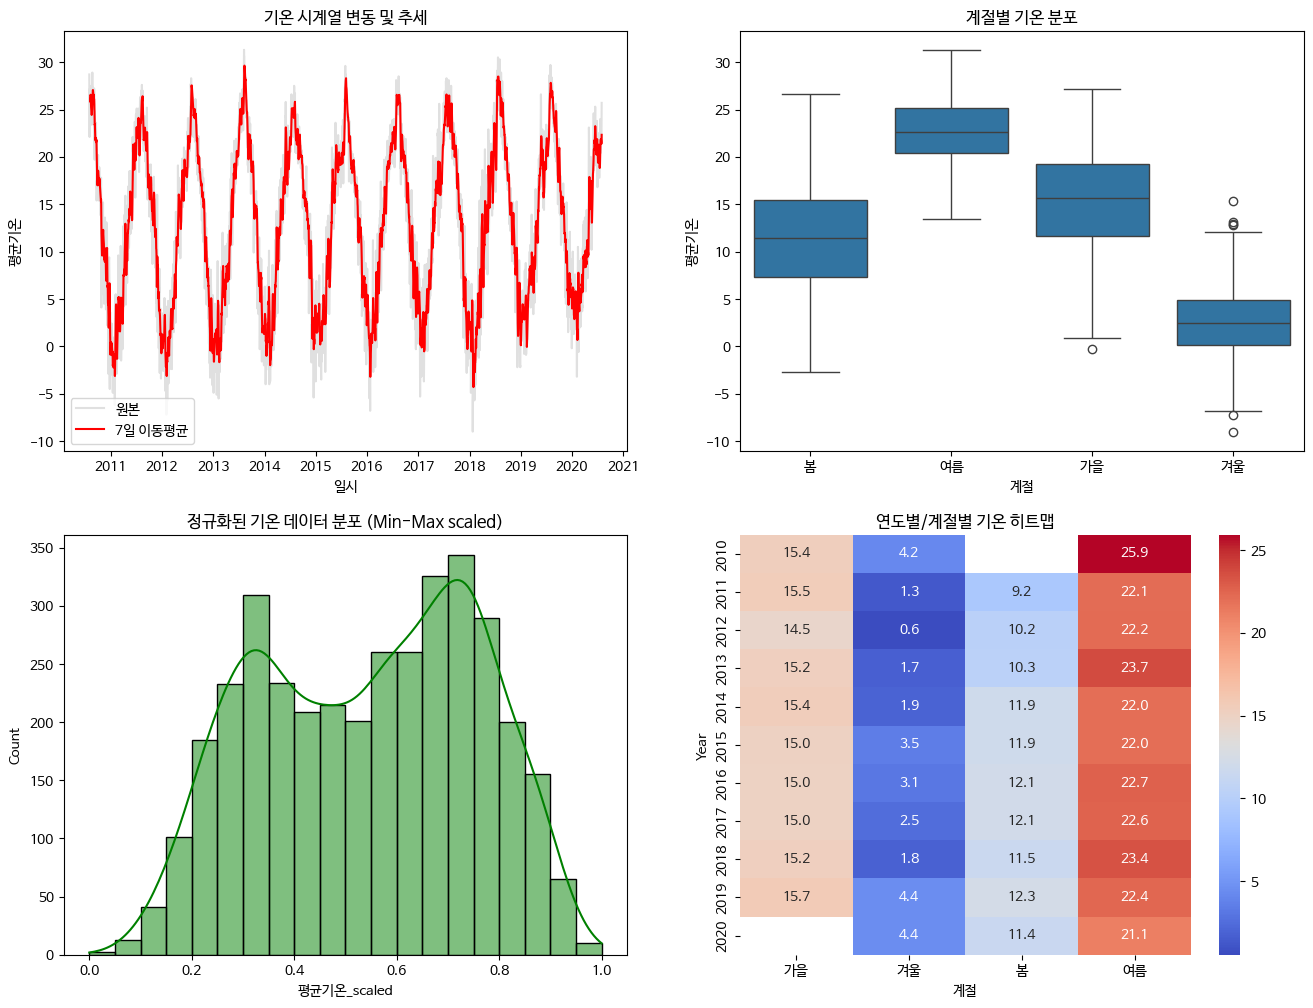

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os
import warnings

# 1. 한글 폰트 설정 -> pandas 실습 할 때 사용한 코드 그대로 사용
def setup_environment():
    warnings.filterwarnings('ignore')

    # 1. 시스템에 나눔 폰트가 있는지 확인 및 설치
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        # Colab 등 리눅스 환경에서 폰트 설치
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 등록
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # 윈도우 환경인 경우 'Malgun Gothic'
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False

setup_environment()

# 2. 데이터 불러오기 url 형식으로 불러오기
def load_weather_data():
    df = pd.read_csv('https://github.com/dongupak/DataML/raw/main/csv/weather.csv', encoding='cp949')
    return df

# 3. 시계열 핸들 -> 과제 핵심 요구 사항
def process_timeseries(df):
    df['일시'] = pd.to_datetime(df['일시'])
    df.set_index('일시', inplace=True)
    df['7일 이동평균'] = df['평균기온'].rolling(window=7).mean()

    # 7주차 데이터분석_파이프라인정리 부분에서 과제에 사용하면 가산점이라고 하셨던 부분-->  df.index.(dayofweek, day) 활용
    df['Year'] = df.index.year
    df['Month'] = df.index.month
    df['Day'] = df.index.day
    df['DayOfWeek'] = df.index.dayofweek

    day_name = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
    df['요일명'] = df['DayOfWeek'].map(day_name)                                       # 7주차 데이터분석_파이프라인정리 부분에서 과제에 사용하면 가산점이라고 하셨던 부분. (map)

    # 계절 변환
    month_to_season = {3:'봄', 4:'봄', 5:'봄', 6:'여름', 7:'여름', 8:'여름',
                       9:'가을', 10:'가을', 11:'가을', 12:'겨울', 1:'겨울', 2:'겨울'}
    df['계절'] = df['Month'].map(month_to_season)

    return df

# 4. 정규화 -> 과제 핵심 요구 사항
def min_max_scaler(df):
    min_val = df['평균기온'].min()
    max_val = df['평균기온'].max()
    df['평균기온_scaled'] = (df['평균기온'] - min_val) / (max_val - min_val)
    return df

# 5. 데이터 재구조화 (과제 필수 조건: groupby, pivot_table) 을 활용하기
def restructure_data(df):
    # groupby 활용
    seasonal_stats = df.groupby('계절')[['평균기온', '최대풍속', '평균풍속']].mean()

    # pivot_table 활용
    yearly_pivot = df.pivot_table(values='평균기온', index='Year', columns='계절', aggfunc='mean')

    # 7주차 데이터분석_파이프라인정리 부분에서 과제에 사용하면 가산점이라고 하셨던 부분. (reindex)
    yearly_pivot = yearly_pivot.reindex(columns=['가을', '겨울', '봄', '여름'])
    return seasonal_stats, yearly_pivot

# 6. 엑셀 저장 to.excel -> 과제 핵심 요구 사항
def export_to_excel(df, seasonal_stats, yearly_pivot):
    with pd.ExcelWriter('weather_analysis_report.xlsx') as writer:
        df.to_excel(writer, sheet_name='전처리 데이터')
        seasonal_stats.to_excel(writer, sheet_name='계절별 통계')
        yearly_pivot.to_excel(writer, sheet_name='연도별 피벗 테이블')

# 7. 그래프 그리기 subplot() 활용
def visualize_results(df, pivot_df):
    plt.figure(figsize=(16, 12))

    # 첫 번째 칸
    plt.subplot(2, 2, 1)
    sns.lineplot(data=df, x=df.index, y='평균기온', color='lightgray', label='원본', alpha=0.7)
    sns.lineplot(data=df, x=df.index, y='7일 이동평균', color='red', label='7일 이동평균')
    plt.title('기온 시계열 변동 및 추세')
    plt.legend(loc='lower left')

    #  두 번째 칸
    plt.subplot(2, 2, 2)
    sns.boxplot(data=df, x='계절', y='평균기온', order=['봄', '여름', '가을', '겨울'], color='tab:blue')    # 7주차 데이터분석_파이프라인정리 부분에서 과제에 사용하면 가산점이라고 하셨던 부분(sns.boxplot)
    plt.title('계절별 기온 분포')

    # [3] 세 번째 칸
    plt.subplot(2, 2, 3)
    sns.histplot(df['평균기온_scaled'], bins=20, kde=True, color='green')                                  # 7주차 데이터분석_파이프라인정리 부분에서 과제에 사용하면 가산점이라고 하셨던 부분(sns.histplot)
    plt.title('정규화된 기온 데이터 분포 (Min-Max scaled)')

    # [4] 네 번째 칸
    plt.subplot(2, 2, 4)
    sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap='coolwarm')                                          # 7주차 데이터분석_파이프라인정리 부분에서 과제에 사용하면 가산점이라고 하셨던 부분(sns.heatmap)
    plt.title('연도별/계절별 기온 히트맵')

    plt.show()

# 8. 메인 제어 함수 main() --> 과제 핵심 요구 사항 --> 위에 독립적인 함수로 만들었던 기능들 사용하기
def main():
    setup_environment()
    df = load_weather_data()
    df = process_timeseries(df)
    df = min_max_scaler(df)
    seasonal_stats, yearly_pivot = restructure_data(df)
    export_to_excel(df, seasonal_stats, yearly_pivot)
    visualize_results(df, yearly_pivot)

# 실행
main()